Best Parameters: {'epochs': 175, 'hidden_layers': [100, 50, 20], 'learning_rate': 0.009, 'mini_batch_size': 42}
Best Score: 0.02364311025484696

In [2]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('data/claims_train.csv')

df1 = pd.read_csv("data/claims_train.csv")
df1['exposure*bonusmalus'] = df1['Exposure'] * df1['BonusMalus']

df1['Density_over_VehAge'] = df1['Density'] / (df1['VehAge'] + 1e-6)
X = df1[['Density', 'DrivAge', 'Exposure', 'VehAge','VehPower', 'BonusMalus', 'VehGas', 'exposure*bonusmalus', 'Density_over_VehAge']]
X = pd.get_dummies(X, drop_first=True, dtype="int")
y = df1['ClaimNb']
X
y_binned = pd.cut(y,bins=5,labels=False,include_lowest=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y_binned)

model = make_pipeline(StandardScaler(), MLPRegressor(
    hidden_layer_sizes=(100,50, 20),  
    activation='relu',
    solver='sgd',#stochastic
    learning_rate_init=0.009,
    batch_size=42,
    max_iter=175, #epochs
    random_state=42,
    early_stopping=True,
    n_iter_no_change=20
))

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test MSE: {mse:.4f}")
print(f"R² Score: {r2:.4f}")


Test MSE: 0.0556
R² Score: 0.0272


c:\Users\Simon\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:697: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


In [3]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

train_mse = []
val_mse = []

mlp = MLPRegressor(
    hidden_layer_sizes=(100, 50, 20),
    activation='relu',
    solver='sgd',
    learning_rate_init=0.009,
    batch_size=42,
    max_iter=1,              # one epoch at a time
    warm_start=True,         # keep weights
    random_state=42
)

model = make_pipeline(StandardScaler(), mlp)

for epoch in range(175):
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_test)

    train_mse.append(mean_squared_error(y_train, y_train_pred))
    val_mse.append(mean_squared_error(y_test, y_val_pred))


/opt/anaconda3/envs/ml/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/ml/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/ml/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/ml/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/ml/lib/python3.13/site-p

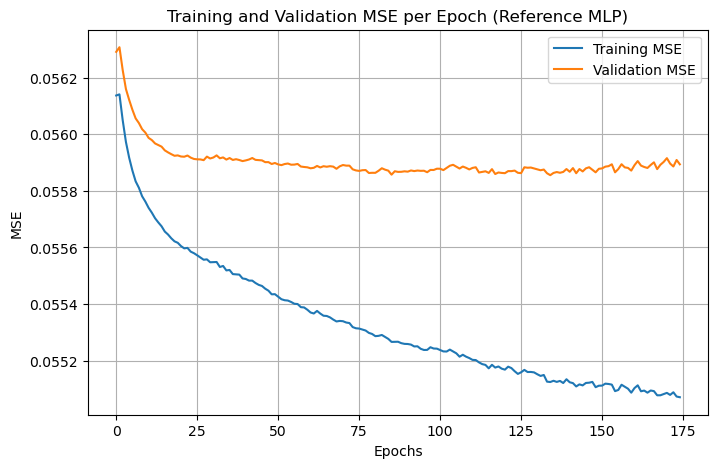

In [4]:
plt.figure(figsize=(8,5))
plt.plot(train_mse, label='Training MSE')
plt.plot(val_mse, label='Validation MSE')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.title('Training and Validation MSE per Epoch (Reference MLP)')
plt.legend()
plt.grid(True)
plt.show()


In [20]:
features = ["Exposure","VehPower","VehAge","DrivAge","BonusMalus","Density","VehBrand_B12","VehGas_Regular"]

df_train = pd.read_csv(R"C:\Users\Simon\Desktop\Project ML\ML-project\data\final_train_data.csv")
df_test = pd.read_csv(R"C:\Users\Simon\Desktop\Project ML\ML-project\data\processed_test_data.csv")
X_train = df_train[features]
y_train = df_train['ClaimNb']
X_test = df_test.drop(columns=['ClaimNb'])
y_test = df_test["ClaimNb"]
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_test


,Exposure,VehPower,VehAge,DrivAge,BonusMalus,Density,VehBrand_B12,VehGas_Regular
0,1.00,5,8,46,50,4116,0,1
1,0.24,4,10,46,64,1329,0,1
2,0.41,4,0,32,72,377,1,1
3,0.07,5,4,57,50,251,0,0
4,0.06,4,10,45,50,94,0,1
...,...,...,...,...,...,...,...,...
135368,0.35,10,6,57,85,879,1,0
135369,0.87,10,10,46,56,1609,0,0
135370,1.00,8,8,35,50,3744,0,1
135371,0.50,11,1,32,54,6485,1,1


In [ ]:


# 1. Define the model
model = models.Sequential([
    
    layers.Dense(100, activation='relu', 
                 kernel_initializer='he_normal', 
                 input_shape=(X_train.shape[1],)),
    layers.Dense(50, activation='relu', 
                 kernel_initializer='he_normal'),
    layers.Dense(20, activation='relu', 
                 kernel_initializer='he_normal'),
    layers.Dense(1, activation='linear')
])

# 2. Compile with your specific Learning Rate
# We use SGD to match your scikit-learn 'solver'
optimizer = tf.keras.optimizers.SGD(learning_rate=0.009)

model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])


# n_iter_no_change=20 in sklearn is 'patience=20' in Keras
early_stop = callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=20, 
    restore_best_weights=True
)

c:\Users\Simon\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.15, 
    epochs=175,
    batch_size=42,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/175
10958/10958 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step - loss: 0.0588 - mae: 0.1070 - val_loss: 0.0584 - val_mae: 0.1266
Epoch 2/175
10958/10958 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step - loss: 0.0562 - mae: 0.0996 - val_loss: 0.0573 - val_mae: 0.1078
Epoch 3/175
10958/10958 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step - loss: 0.0561 - mae: 0.0993 - val_loss: 0.0572 - val_mae: 0.1009
Epoch 4/175
10958/10958 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step - loss: 0.0560 - mae: 0.0990 - val_loss: 0.0576 - val_mae: 0.1198
Epoch 5/175
10958/10958 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step - loss: 0.0560 - mae: 0.0989 - val_loss: 0.0571 - val_mae: 0.0979
Epoch 6/175
10958/10958 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step - loss: 0.0559 - mae: 0.0988 - val_loss: 0.0571 - val_mae: 0.0953
Epoch 7/175
10958/10958 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step - loss: 0.0559 - mae: 0.0987 - val_loss: 0.0570 - val_mae: 0.0985
Epoch 8/175
10958/10958 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step - loss: 0.0558 - mae: 0.0987 - val_loss: 0.0573 - val_mae: 0.0890
Epoch 9/

In [23]:
y_pred_raw = model.predict(X_test_scaled)

4231/4231 ━━━━━━━━━━━━━━━━━━━━ 2s 544us/step


In [24]:
y_pred = y_pred_raw.flatten()
y_test

0         0
1         0
2         0
3         0
4         0
         ..
135368    0
135369    0
135370    0
135371    0
135372    0
Name: ClaimNb, Length: 135373, dtype: int64

In [26]:
score = r2_score(y_test, y_pred)

print(f"Model R^2 Score: {score:.4f}")

Model R^2 Score: 0.0290
